# Manifold Tree Builder - Test Notebook

Tests for `hyperbolic_tree.py`: projection onto Riemannian manifolds and parent-child tree construction.

Supported manifolds: Lorentz, Poincaré ball, Sphere, Euclidean.

In [1]:
import sys
sys.path.insert(0, '..')

import torch
from hhs.hyperbolic_tree import (
    build_trees, project_to_manifold, build_parent_child_trees,
    pairwise_distances, MANIFOLD_REGISTRY,
)
from geoopt.manifolds.lorentz import Lorentz
from geoopt.manifolds.stereographic import PoincareBall
from geoopt.manifolds.sphere import Sphere
from geoopt.manifolds.euclidean import Euclidean

/home/alexpv/anaconda3/envs/tc_clip/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Test projection to Lorentz manifold

In [2]:
manifold = Lorentz(k=1.0).double()
vectors = torch.randn(7, 64).double()

print("Input shape:", vectors.shape)
projected = project_to_manifold(vectors, manifold)
print("Projected shape:", projected.shape)
print("Projected vectors:")
print(projected)

Input shape: torch.Size([7, 64])
Projected shape: torch.Size([7, 65])
Projected vectors:
tensor([[ 2.9875e+03,  3.5212e+02, -3.7065e+02,  4.2539e+02,  8.8908e+01,
          5.8768e+02,  2.0886e+02,  7.3091e+01,  3.7042e+02,  1.0206e+02,
          3.4854e+02,  2.0800e+02, -5.3891e+00, -7.1151e+02, -5.3924e+02,
         -4.7070e+02, -8.2419e+02,  1.6564e+02, -3.9829e+02,  1.9181e+02,
         -1.1588e+01,  2.3893e+02, -1.1226e+02, -4.0930e+02, -1.9207e+02,
         -2.8564e+02, -4.9171e+01, -5.6534e+02, -1.2487e+02,  3.9273e+02,
          9.8917e+01,  3.3179e+02, -3.7785e+01, -1.1432e+02,  1.8983e+02,
         -4.6010e+02, -1.2825e+02, -2.6215e+02, -7.8711e+01,  8.5507e+02,
          2.8423e+02,  1.2855e+02,  1.6403e+02,  7.7624e+02, -2.1238e+02,
         -3.5894e+02,  1.1764e+02,  1.4862e+01, -4.5574e+02, -2.1112e+01,
         -3.5407e+02,  2.6435e+02,  3.3500e+02, -6.4513e+02, -6.5446e+02,
          3.8696e+02, -2.7258e+02,  5.7953e+02,  2.6953e+02,  1.6604e+02,
          1.4991e+02, -

In [3]:
# Verify all points satisfy the Lorentz constraint: -x0^2 + x1^2 + ... + xd^2 = -k
ok, reason = manifold._check_point_on_manifold(projected)
print(f"Points on manifold: {ok}")
print(f"Reason: {reason}")
assert ok, f"Projection failed: {reason}"

Points on manifold: True
Reason: None


## 2. Test pairwise distances

In [4]:
parents = torch.randn(7, 64).double()
children = torch.randn(15, 64).double()

manifold_d = Lorentz(k=1.0).double()
parents_proj = project_to_manifold(parents, manifold_d)
children_proj = project_to_manifold(children, manifold_d)

dist_matrix = manifold_d.cdist(parents_proj, children_proj)
print("Distance matrix shape:", dist_matrix.shape)
print("Distance matrix:")
print(dist_matrix)
print()
print("All distances positive:", (dist_matrix >= 0).all().item())

Distance matrix shape: torch.Size([7, 15])
Distance matrix:
tensor([[14.8998, 17.2285, 14.2409, 16.1694, 15.4280, 15.1243, 15.4751, 15.6591,
         14.8000, 16.8405, 15.8495, 14.6036, 15.8373, 13.9610, 16.8380],
        [13.3162, 15.3054, 12.2866, 14.0231, 13.3461, 13.2951, 13.4749, 13.8069,
         13.0148, 14.8710, 13.9833, 12.9723, 13.8991, 12.1202, 15.1381],
        [14.0410, 15.9694, 13.3847, 15.2775, 14.0166, 14.3486, 14.3217, 14.5853,
         14.1993, 15.6350, 14.7897, 13.4423, 14.8855, 12.9846, 15.8773],
        [14.5144, 16.6652, 14.0257, 15.8326, 15.1442, 14.9678, 15.1760, 15.4337,
         14.7934, 16.1875, 15.4418, 14.2741, 15.6351, 13.5687, 16.3767],
        [14.8620, 16.5807, 13.8816, 15.8123, 14.9664, 14.9203, 14.8304, 15.3519,
         14.5696, 16.1949, 15.2893, 14.1273, 15.3299, 13.3066, 16.4374],
        [14.4269, 16.5192, 13.5240, 15.3858, 14.7424, 14.4390, 14.5260, 14.9510,
         14.2306, 15.8121, 15.1030, 13.7749, 14.9718, 12.9822, 16.0574],
        [14.4918

## 3. Test build_parent_child_trees

In [5]:
tree = build_parent_child_trees(parents_proj, children_proj, manifold_d)
print("Tree:")
for parent, children_set in tree.items():
    print(f"  {parent}: {children_set}")

total = sum(len(v) for v in tree.values())
print(f"\nTotal children assigned: {total}")
assert total == 15, f"Expected 15, got {total}"

Tree:
  parent_0: set()
  parent_1: {'child_14', 'child_10', 'child_6', 'child_3', 'child_7', 'child_8', 'child_13', 'child_9', 'child_0', 'child_11', 'child_1', 'child_4', 'child_2', 'child_12', 'child_5'}
  parent_2: set()
  parent_3: set()
  parent_4: set()
  parent_5: set()
  parent_6: set()

Total children assigned: 15


## 4. Test full pipeline (build_trees)

In [6]:
parent_vecs = torch.randn(7, 64).double()
child_vecs = torch.randn(15, 64).double()

tree = build_trees(
    parent_vecs, child_vecs,
    curvature=1.0,
    parent_labels=["scene", "object_A", "object_B", "object_C", "object_D", "object_E", "object_F"],
    child_labels=[f"slot_{i}" for i in range(15)],
)

print("Tree with custom labels:")
for parent, children_set in tree.items():
    print(f"  {parent}: {children_set}")

total = sum(len(v) for v in tree.values())
assert total == 15, f"Expected 15, got {total}"
assert len(tree) == 7, f"Expected 7 parents, got {len(tree)}"
print("\nAll assertions passed!")

Tree with custom labels:
  scene: set()
  object_A: set()
  object_B: set()
  object_C: set()
  object_D: set()
  object_E: {'slot_0', 'slot_2', 'slot_4', 'slot_7', 'slot_6', 'slot_8', 'slot_1', 'slot_5', 'slot_3', 'slot_13', 'slot_12', 'slot_11', 'slot_9', 'slot_14', 'slot_10'}
  object_F: set()

All assertions passed!


## 5. Edge case: empty inputs

In [7]:
empty_tree = build_trees(torch.randn(3, 5).double(), torch.randn(0, 5).double())
print("Empty children:", empty_tree)
assert all(len(v) == 0 for v in empty_tree.values())
print("Edge case passed!")

Empty children: {'parent_0': set(), 'parent_1': set(), 'parent_2': set()}
Edge case passed!


## 6. Multi-manifold tests

Verify that the pipeline works with all supported manifolds: Poincaré ball, Sphere, and Euclidean.

In [8]:
### Poincaré ball
poincare = PoincareBall(c=1.0).double()
vecs = torch.randn(5, 4).double() * 0.5  # keep small to stay inside ball

proj = project_to_manifold(vecs, poincare)
print("Poincaré — input shape:", vecs.shape, "-> projected shape:", proj.shape)

# Verify points are inside the ball: ||x|| < 1/sqrt(c)
norms = proj.norm(dim=-1)
print("Norms:", norms)
assert (norms < 1.0).all(), f"Points outside Poincaré ball: {norms}"

# Pairwise distances (uses broadcast fallback since PoincareBall has no cdist)
p = proj[:2]
c = proj[2:]
dists = pairwise_distances(p, c, poincare)
print("Distance matrix shape:", dists.shape)
print("Distance matrix:\n", dists)
assert (dists >= 0).all(), "Negative distances found"
print("\nPoincaré tests passed!")

Poincaré — input shape: torch.Size([5, 4]) -> projected shape: torch.Size([5, 4])
Norms: tensor([0.7883, 0.8612, 0.9375, 0.4626, 0.5809], dtype=torch.float64)
Distance matrix shape: torch.Size([2, 3])
Distance matrix:
 tensor([[5.2436, 2.5902, 1.0328],
        [5.1199, 2.4524, 3.1488]], dtype=torch.float64)

Poincaré tests passed!


In [9]:
### Sphere
sphere = Sphere()
vecs_s = torch.randn(5, 4).double()

proj_s = project_to_manifold(vecs_s, sphere)
print("Sphere — input shape:", vecs_s.shape, "-> projected shape:", proj_s.shape)

# Verify points lie on the unit sphere: ||x|| = 1
norms_s = proj_s.norm(dim=-1)
print("Norms:", norms_s)
assert torch.allclose(norms_s, torch.ones_like(norms_s), atol=1e-6), f"Not on sphere: {norms_s}"

# Pairwise distances (Sphere has cdist)
p_s = proj_s[:2]
c_s = proj_s[2:]
dists_s = pairwise_distances(p_s, c_s, sphere)
print("Distance matrix shape:", dists_s.shape)
print("Distance matrix:\n", dists_s)
assert (dists_s >= 0).all(), "Negative distances found"
print("\nSphere tests passed!")

Sphere — input shape: torch.Size([5, 4]) -> projected shape: torch.Size([5, 4])
Norms: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000], dtype=torch.float64)
Distance matrix shape: torch.Size([2, 3])
Distance matrix:
 tensor([[1.9218, 2.5223, 0.5579],
        [2.0391, 2.0019, 1.0018]], dtype=torch.float64)

Sphere tests passed!


In [10]:
### Euclidean
euclidean = Euclidean(ndim=1)
vecs_e = torch.randn(5, 4).double()

proj_e = project_to_manifold(vecs_e, euclidean)
print("Euclidean — input shape:", vecs_e.shape, "-> projected shape:", proj_e.shape)

# Euclidean projection is identity
assert torch.equal(vecs_e, proj_e), "Euclidean projection should be identity"

# Pairwise distances
p_e = proj_e[:2]
c_e = proj_e[2:]
dists_e = pairwise_distances(p_e, c_e, euclidean)
print("Distance matrix shape:", dists_e.shape)
print("Distance matrix:\n", dists_e)
assert (dists_e >= 0).all(), "Negative distances found"
print("\nEuclidean tests passed!")

Euclidean — input shape: torch.Size([5, 4]) -> projected shape: torch.Size([5, 4])
Distance matrix shape: torch.Size([2, 3])
Distance matrix:
 tensor([[1.1602, 1.7977, 1.7498],
        [2.5818, 2.0058, 5.0629]], dtype=torch.float64)

Euclidean tests passed!


In [11]:
### Full pipeline with all manifolds via string API
parent_v = torch.randn(4, 6).double()
child_v = torch.randn(10, 6).double()
plabels = [f"P{i}" for i in range(4)]
clabels = [f"C{j}" for j in range(10)]

for name in MANIFOLD_REGISTRY:
    tree = build_trees(
        parent_v, child_v,
        manifold=name,
        curvature=1.0,
        parent_labels=plabels,
        child_labels=clabels,
    )
    total = sum(len(v) for v in tree.values())
    assert total == 10, f"{name}: expected 10 children, got {total}"
    assert len(tree) == 4, f"{name}: expected 4 parents, got {len(tree)}"
    print(f"{name:>10s}: {dict((k, sorted(v)) for k, v in tree.items())}")

print("\nAll manifold pipeline tests passed!")

   lorentz: {'P0': ['C1'], 'P1': ['C0', 'C7'], 'P2': ['C2', 'C3', 'C4', 'C5', 'C6', 'C8', 'C9'], 'P3': []}
  poincare: {'P0': [], 'P1': [], 'P2': ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9'], 'P3': []}
    sphere: {'P0': ['C1', 'C3', 'C4', 'C5'], 'P1': ['C0', 'C7', 'C8', 'C9'], 'P2': [], 'P3': ['C2', 'C6']}
 euclidean: {'P0': ['C1'], 'P1': ['C0', 'C7', 'C8'], 'P2': ['C3', 'C4', 'C5', 'C6', 'C9'], 'P3': ['C2']}

All manifold pipeline tests passed!


## 7. Visualization of parent-child trees

Using 2D input vectors so the spatial components on the hyperboloid are directly plottable.

In [12]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 2D input vectors -> 3D on hyperboloid -> spatial components are 2D
n_parents = 7
n_children = 15

parent_labels = [f"P{i}" for i in range(n_parents)]
child_labels = [f"C{j}" for j in range(n_children)]

# Parents close to origin (small std), children further out (larger std)
vis_parents = torch.randn(n_parents, 2).double() * 0.3
vis_children = torch.randn(n_children, 2).double() * 1.5

# Project onto hyperboloid
vis_manifold = Lorentz(k=1.0).double()
parents_hyp = project_to_manifold(vis_parents, vis_manifold)
children_hyp = project_to_manifold(vis_children, vis_manifold)

# Pairwise distances and tree
dist_matrix = vis_manifold.cdist(parents_hyp, children_hyp)
tree = build_parent_child_trees(
    parents_hyp, children_hyp, vis_manifold,
    parent_labels=parent_labels, child_labels=child_labels,
)

# Spatial components (drop x_0)
parents_spatial = parents_hyp[:, 1:].detach().numpy()
children_spatial = children_hyp[:, 1:].detach().numpy()

print("Tree assignments:")
for p, cs in tree.items():
    print(f"  {p}: {cs}")
print(f"\nDistance matrix shape: {dist_matrix.shape}")

Tree assignments:
  P0: {'C3', 'C13', 'C1', 'C0', 'C8', 'C4'}
  P1: {'C11', 'C6', 'C10'}
  P2: {'C12', 'C7'}
  P3: {'C2', 'C14'}
  P4: set()
  P5: {'C5', 'C9'}
  P6: set()

Distance matrix shape: torch.Size([7, 15])


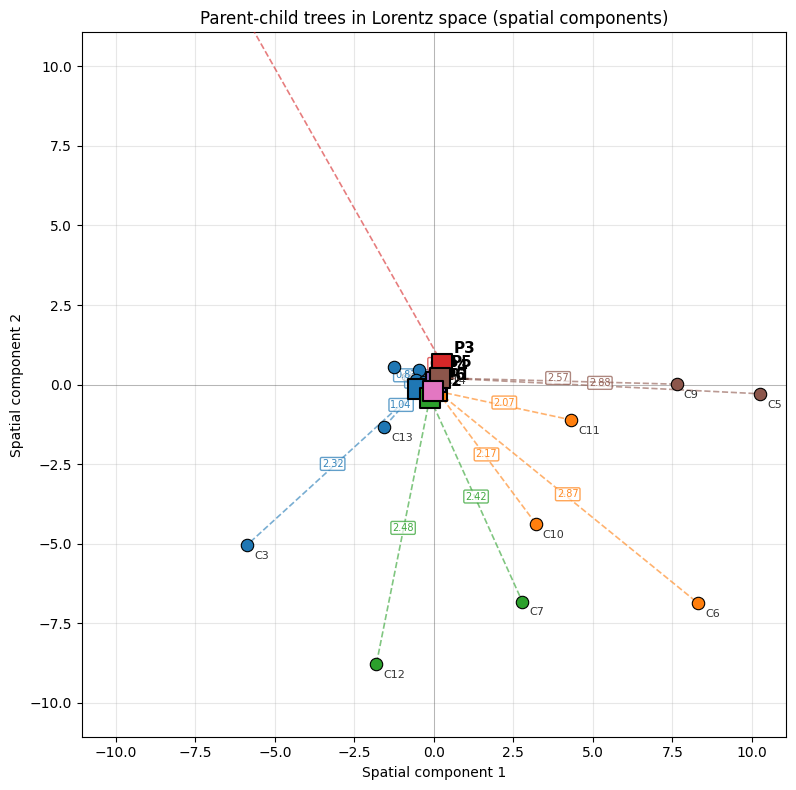

In [13]:
colors = list(mcolors.TABLEAU_COLORS.values())
child_label_to_idx = {label: j for j, label in enumerate(child_labels)}

fig, ax = plt.subplots(figsize=(10, 8))

for i, (plabel, child_set) in enumerate(tree.items()):
    color = colors[i % len(colors)]
    px, py = parents_spatial[i]

    # Parent: large square
    ax.scatter(px, py, s=200, c=color, marker="s", edgecolors="black",
               linewidths=1.5, zorder=5)
    ax.annotate(plabel, (px, py), textcoords="offset points",
                xytext=(8, 8), fontsize=11, fontweight="bold")

    # Children + connecting lines
    for clabel in child_set:
        j = child_label_to_idx[clabel]
        cx, cy = children_spatial[j]
        d = dist_matrix[i, j].item()

        ax.scatter(cx, cy, s=80, c=color, marker="o", edgecolors="black",
                   linewidths=0.8, zorder=4)
        ax.plot([px, cx], [py, cy], color=color, linewidth=1.2,
                linestyle="--", alpha=0.6, zorder=3)
        ax.annotate(clabel, (cx, cy), textcoords="offset points",
                    xytext=(5, -10), fontsize=8, alpha=0.8)

        # Distance label at midpoint
        mx, my = (px + cx) / 2, (py + cy) / 2
        ax.annotate(f"{d:.2f}", (mx, my), fontsize=7, color=color,
                    alpha=0.9, ha="center",
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec=color, alpha=0.7))

# Center plot at origin with symmetric limits
import numpy as np
all_x = np.concatenate([parents_spatial[:, 0], children_spatial[:, 0]])
all_y = np.concatenate([parents_spatial[:, 1], children_spatial[:, 1]])
lim = max(np.abs(all_x).max(), np.abs(all_y).max()) / 2
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)

ax.axhline(0, color="black", linewidth=0.5, alpha=0.3)
ax.axvline(0, color="black", linewidth=0.5, alpha=0.3)
ax.set_xlabel("Spatial component 1")
ax.set_ylabel("Spatial component 2")
ax.set_title("Parent-child trees in Lorentz space (spatial components)")
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()